# Resovoir Data Analysis

### Load Packages and Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Start by reading the CSV file from the path into a DataFrame.
df = pd.read_csv(r"../../Pensum/D2Dbook/data/reservoirs.csv")


### Translate Norwegian Columns

In [2]:
# Translating Norwegian column names into understandable English.
df = df.rename(columns={
    "dato_Id": "Date",
    "omrType": "Area Type",
    "omrnr": "Area Number",
    "iso_aar": "ISO Year",
    "iso_uke": "ISO Week",
    "fyllingsgrad": "Filling Ratio",
    "kapasitet_TWh": "Capacity TWh",
    "fylling_TWh": "Filling TWh",
    "neste_Publiseringsdato": "Next Publishing Date",
    "fyllingsgrad_forrige_uke": "FR Last Week",
    "endring_fyllingsgrad": "Change FR",
})


### Sort Columns by User Input

In [3]:
# Setting up sorting by date.
df["Date"] = pd.to_datetime(df["Date"])
# df = df.sort_values("Date", ascending=True)
# df = df.sort_values("Area Number", ascending=True)

# Sorting by user input.
sort = input("Welcome, User\n"
            "Select sorting column:\n" \
            "1 - Date (oldest-newest)\n" \
            "2 - Date (newest-oldest)")

if sort == "1":
    df = df.sort_values("Date", ascending=True)
elif sort == "2":
    df = df.sort_values("Date", ascending=False)
else:
    print("Invalid choice.")


### Plotting Columns Individually

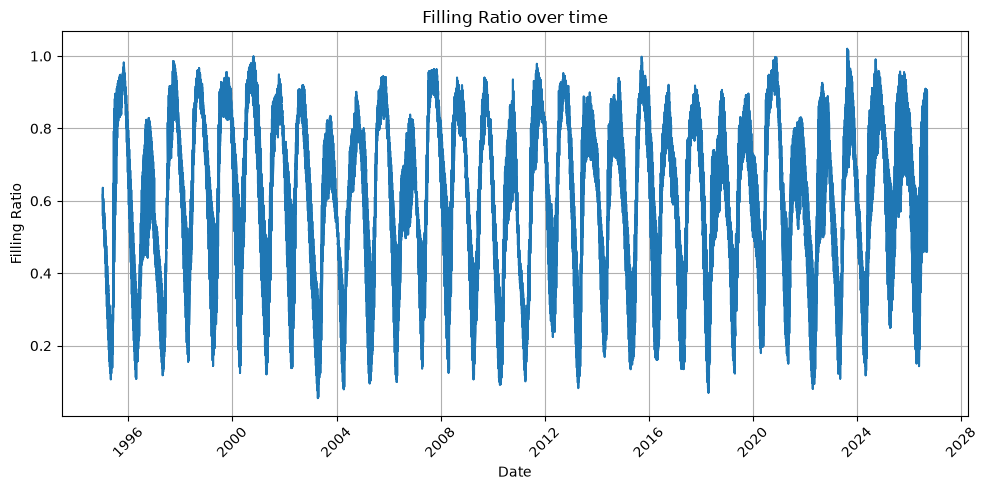

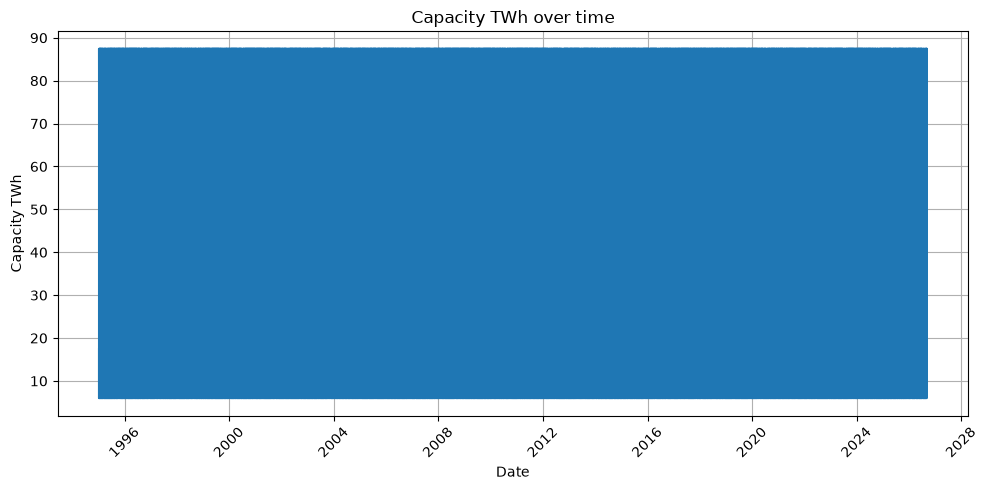

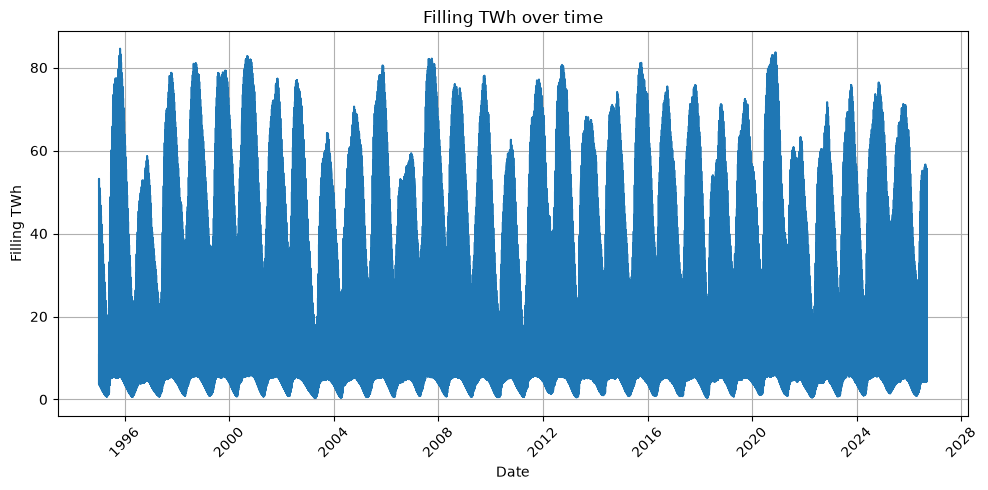

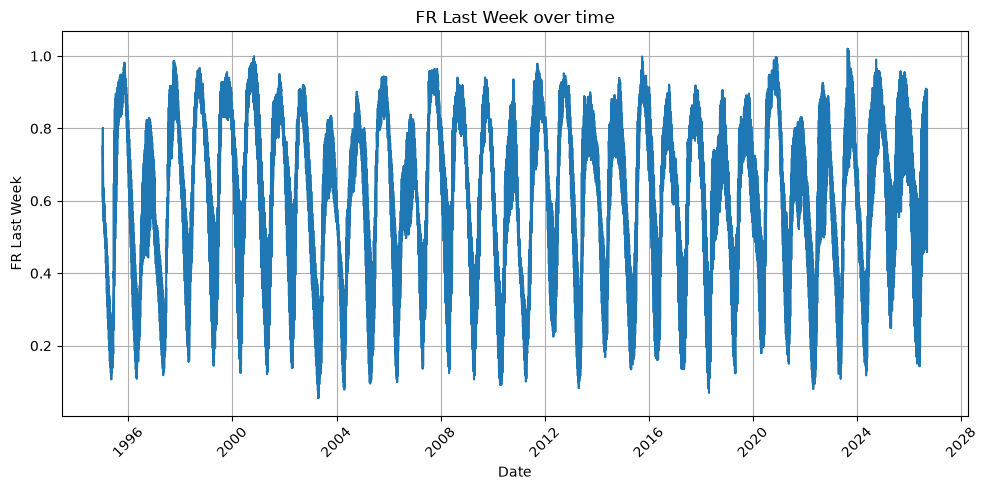

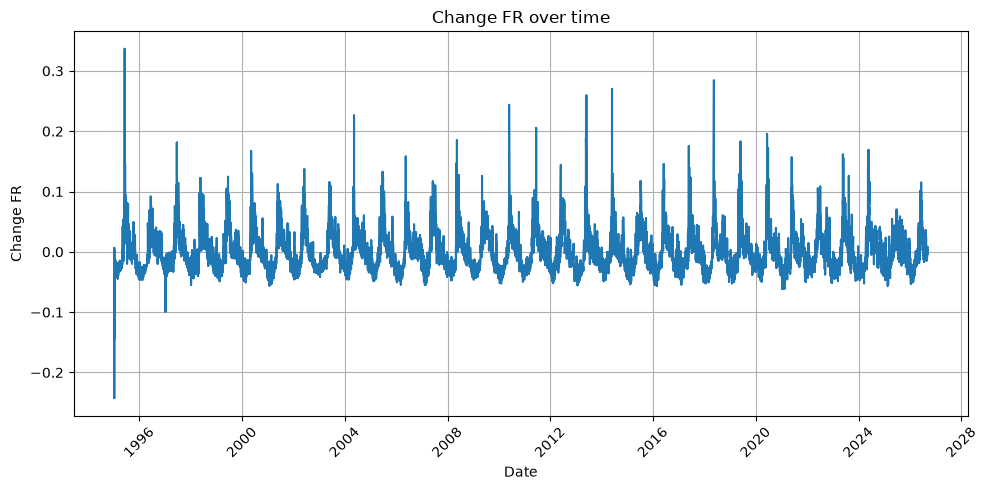

In [4]:
# Picking out columns to plot individually.
columns_to_plot = [
    "Filling Ratio",
    "Capacity TWh",
    "Filling TWh",
    "FR Last Week",
    "Change FR",
]

# Plotting selected columns for individual plotting.
for column in columns_to_plot:
    plt.figure(figsize=(10, 5))
    plt.plot(df["Date"], df[column])
    
    plt.title(f"{column} over time")
    plt.xlabel("Date")
    plt.ylabel(column)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Plotting Columns Together

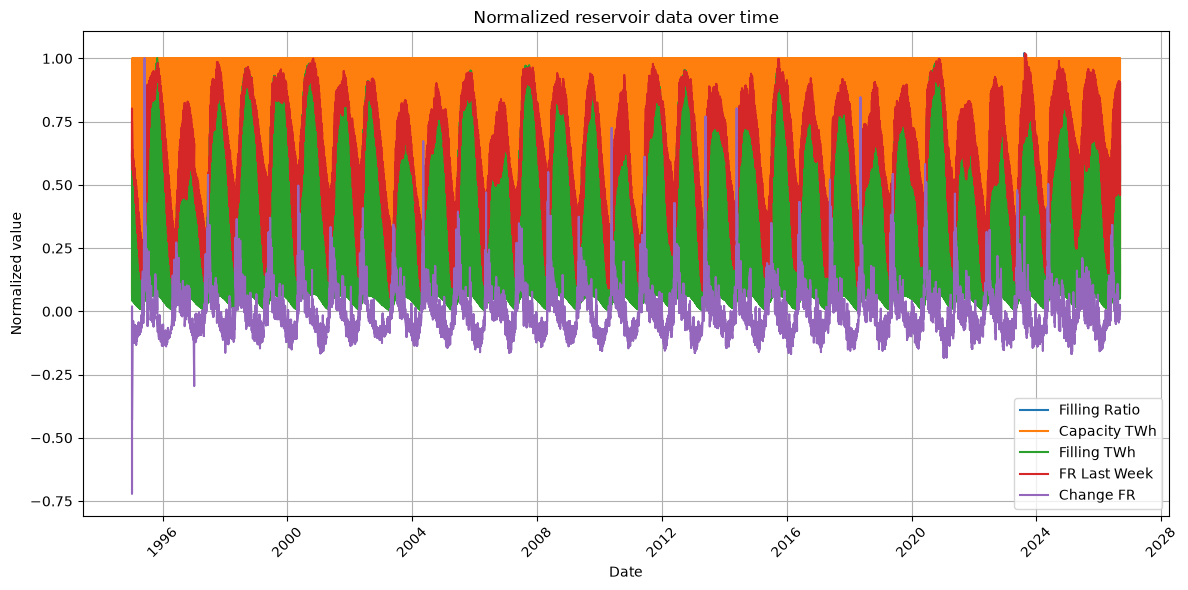

In [5]:
# Plotting selected columns together in one figure.
# Copy of df for plotting, keeps user-sorted df.
plot_df = df.sort_values("Date")

# Tagging columns already defined by ratio numbers.
ratio_columns = [
    "Filling Ratio",
    "FR Last Week",
]

# Converting non-ratio columns into ratio columns for plotting in one figure.
normalized_df = plot_df[["Date"]].copy()

for column in columns_to_plot:
    if column in ratio_columns:
        normalized_df[column] = plot_df[column]
    else:
        maximum = plot_df[column].abs().max()
        normalized_df[column] = plot_df[column] / maximum

# Plotting all selected columns in one figure.
plt.figure(figsize=(12, 6))

for column in columns_to_plot:
    plt.plot(
        normalized_df["Date"],
        normalized_df[column],
        label=column
    )

plt.title("Normalized reservoir data over time")
plt.xlabel("Date")
plt.ylabel("Normalized value")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Print Data Sorted by User Input

In [6]:
print(df.head())
print(df.tail())


           Date Area Type  Area Number  ISO Year  ISO Week  Filling Ratio  \
3468 1995-01-08        EL            5      1995         1       0.616448   
3361 1995-01-08        EL            4      1995         1       0.558864   
5036 1995-01-08        EL            3      1995         1       0.602376   
3113 1995-01-08        EL            1      1995         1       0.621467   
7739 1995-01-08        EL            2      1995         1       0.630947   

      Capacity TWh  Filling TWh Next Publishing Date  FR Last Week  Change FR  
3468     17.390587    10.720388  0001-01-01T00:00:00      0.614288   0.002160  
3361     21.079208    11.780413  0001-01-01T00:00:00      0.801348  -0.242484  
5036      8.920932     5.373754  0001-01-01T00:00:00      0.596027   0.006349  
3113      6.003264     3.730831  0001-01-01T00:00:00      0.734888  -0.113421  
7739     34.043590    21.479713  0001-01-01T00:00:00      0.777604  -0.146657  
            Date Area Type  Area Number  ISO Year  ISO We